# Logistic Regression on E-commerce Customer Churn

Implementation of binary classification using logistic regression from scratch:
- Sigmoid function
- Binary cross-entropy loss
- Gradient descent

Target: predict whether a customer will churn (`churned = 1`) or not (`churned = 0`).  
Only numerical features are used — categorical handling comes later.

## Dataset
E-commerce customer behavior dataset from Kaggle: [E-Commerce Customer Behavior and Sales 2020–2026](https://www.kaggle.com/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026).  
8,000 customers with purchase history, engagement metrics, and demographics.  
Features used: `age`, `total_orders`, `total_spend_usd`, `avg_order_value_usd`,
`days_since_last_purchase`, `reviews_given`, `avg_review_score`, `returns_made`,
`wishlist_items`, `newsletter_subscribed`.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [2]:
df = pd.read_csv("data/customers.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8000, 20)


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


### Exploration

In [4]:
df.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

Not churned (0): 7,285 (91.1%)
Churned     (1): 715 (8.9%)


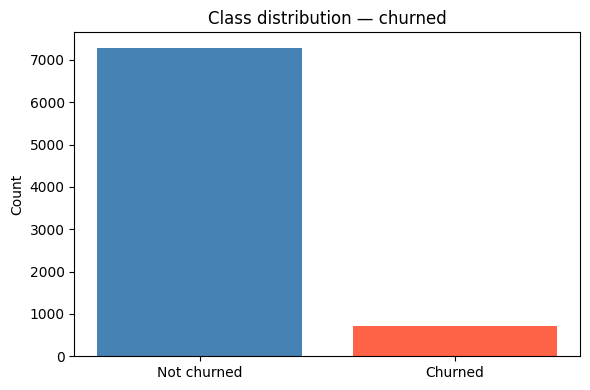

In [9]:
churn_counts = df["churned"].value_counts()
print(f"Not churned (0): {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned     (1): {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(["Not churned", "Churned"], churn_counts.values, color=["steelblue", "tomato"])
plt.title("Class distribution — churned")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:
feature_cols = [
    "age", "total_orders", "total_spend_usd", "avg_order_value_usd",
    "days_since_last_purchase", "reviews_given", "avg_review_score",
    "returns_made", "wishlist_items", "newsletter_subscribed"
]

df[feature_cols + ["churned"]].describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000
